<a href="https://colab.research.google.com/github/RoHaN-0053/Healthcare-Churn-prediction/blob/main/Healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load and Analyize Data


In [52]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Untitled Folder/healthcare_project/patient_churn_dataset.csv")

In [53]:
df.head()

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1


In [54]:
df.describe()

,Age,Tenure_Months,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,52.856500,60.733500,7.614000,2.028000,366.130000,3.255000,3.289900,3.525900,3.736100,836.544000,0.078500,0.206000,1.483500,25.167400,0.683500
std,15.836487,35.111293,4.672143,1.699312,212.890277,1.008595,1.009062,0.871613,0.733748,589.031896,0.269024,0.404532,1.100151,13.948284,0.465227
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.500000,1.500000,2.000000,2.500000,20.000000,0.000000,0.000000,0.000000,0.500000,0.000000
25%,41.000000,30.000000,4.000000,0.000000,180.000000,2.400000,2.400000,2.775000,3.100000,326.000000,0.000000,0.000000,1.000000,12.800000,0.000000
50%,54.000000,60.000000,8.000000,2.000000,363.000000,3.200000,3.300000,3.500000,3.800000,716.000000,0.000000,0.000000,1.000000,25.000000,1.000000
75%,65.000000,92.250000,12.000000,3.000000,550.250000,4.100000,4.100000,4.300000,4.400000,1368.250000,0.000000,0.000000,2.000000,37.200000,1.000000
max,90.000000,120.000000,15.000000,5.000000,730.000000,5.000000,5.000000,5.000000,5.000000,1999.000000,1.000000,1.000000,3.000000,50.000000,1.000000


In [55]:
df.shape

(2000, 21)

In [56]:
df.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
State,0
Tenure_Months,0
Specialty,0
Insurance_Type,0
Visits_Last_Year,0
Missed_Appointments,0
Days_Since_Last_Visit,0


In [57]:
df["Insurance_Type"].unique()

array(['Medicaid', 'Self-Pay', 'Private', 'Medicare'], dtype=object)

In [58]:
df.drop_duplicates()



,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,C21995,31,Male,NC,78,Internal Medicine,Medicare,8,2,180,...,3.9,1.8,2.4,2.9,268,0,1,0,42.6,1
1996,C21996,45,Female,GA,69,Internal Medicine,Private,6,4,352,...,4.2,2.8,3.5,4.6,1257,1,0,3,15.4,1
1997,C21997,37,Male,NC,91,Family Medicine,Medicare,9,4,494,...,3.9,2.7,3.0,2.7,50,0,1,3,2.6,0
1998,C21998,69,Female,NY,5,Internal Medicine,Private,3,0,315,...,1.7,3.2,3.6,4.2,848,0,0,1,38.8,1


# EDA

<Axes: xlabel='Age', ylabel='Count'>

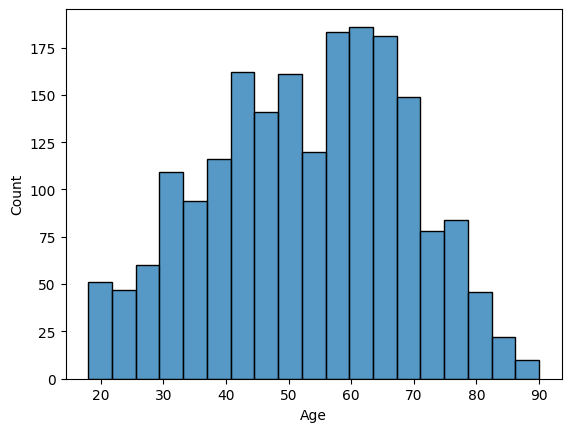

In [59]:
sns.histplot(
    data = df,
    x = "Age"
)

In [60]:
df["Churned"].value_counts()

,count
Churned,
1,1367
0,633


([<matplotlib.patches.Wedge at 0x7d21d65e39b0>,
 [Text(-0.5995858669452556, 0.9222238275817354, 'Churned'),
  Text(0.5995863873191201, -0.9222234892593044, 'Not Churned')],
 [Text(-0.3270468365155939, 0.5030311786809465, '68.3%'),
  Text(0.3270471203558836, -0.5030309941414387, '31.7%')])

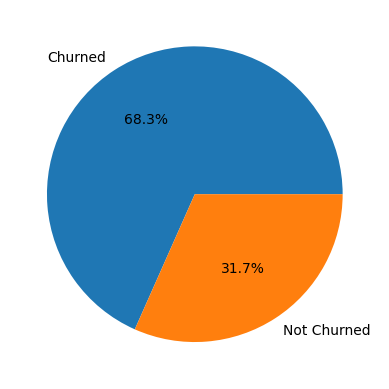

In [61]:
plt.pie(df["Churned"].value_counts(),labels = ["Churned","Not Churned"],autopct = "%1.1f%%")

In [62]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'State', 'Tenure_Months', 'Specialty',
       'Insurance_Type', 'Visits_Last_Year', 'Missed_Appointments',
       'Days_Since_Last_Visit', 'Last_Interaction_Date',
       'Overall_Satisfaction', 'Wait_Time_Satisfaction', 'Staff_Satisfaction',
       'Provider_Rating', 'Avg_Out_Of_Pocket_Cost', 'Billing_Issues',
       'Portal_Usage', 'Referrals_Made', 'Distance_To_Facility_Miles',
       'Churned'],
      dtype='object')

<Axes: xlabel='Insurance_Type', ylabel='Age'>

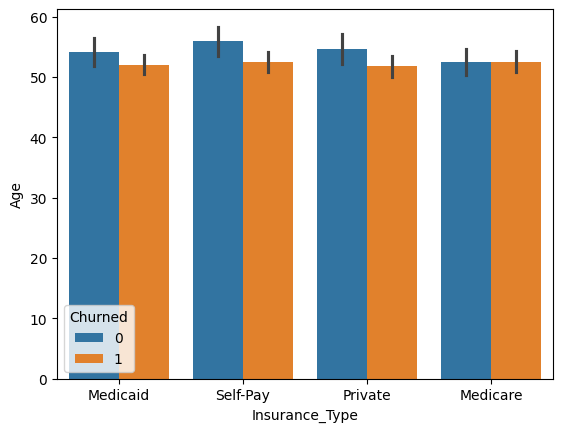

In [63]:
sns.barplot(
    data = df,
    x = "Insurance_Type",
    y = "Age",
    hue = "Churned"

)

In [64]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["State"] = le.fit_transform(df["State"])
df["Specialty"] = le.fit_transform(df["Specialty"])
df["Insurance_Type"] = le.fit_transform(df["Insurance_Type"])

In [65]:
df

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,0,8,62,6,0,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,0,2,44,3,3,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,1,4,120,3,0,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,1,1,118,2,2,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,0,0,70,0,0,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,C21995,31,1,5,78,3,1,8,2,180,...,3.9,1.8,2.4,2.9,268,0,1,0,42.6,1
1996,C21996,45,0,2,69,3,2,6,4,352,...,4.2,2.8,3.5,4.6,1257,1,0,3,15.4,1
1997,C21997,37,1,5,91,1,1,9,4,494,...,3.9,2.7,3.0,2.7,50,0,1,3,2.6,0
1998,C21998,69,0,6,5,3,2,3,0,315,...,1.7,3.2,3.6,4.2,848,0,0,1,38.8,1


In [66]:
df = df.drop(columns=["PatientID"])

In [67]:
df

,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,Last_Interaction_Date,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,41,0,8,62,6,0,1,0,564,2024-07-05,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,43,0,2,44,3,3,7,4,254,2025-05-11,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,21,1,4,120,3,0,15,5,89,2025-10-23,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,65,1,1,118,2,2,10,3,135,2025-09-07,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,18,0,0,70,0,0,5,4,696,2024-02-24,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,31,1,5,78,3,1,8,2,180,2025-07-24,3.9,1.8,2.4,2.9,268,0,1,0,42.6,1
1996,45,0,2,69,3,2,6,4,352,2025-02-02,4.2,2.8,3.5,4.6,1257,1,0,3,15.4,1
1997,37,1,5,91,1,1,9,4,494,2024-09-13,3.9,2.7,3.0,2.7,50,0,1,3,2.6,0
1998,69,0,6,5,3,2,3,0,315,2025-03-11,1.7,3.2,3.6,4.2,848,0,0,1,38.8,1


In [68]:
X = df.drop(columns=["Churned", "Last_Interaction_Date"],axis=1)
y = df["Churned"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)


X_test = scaler.transform(X_test)




##Logistic Regression


In [69]:
#Logistic +  standarization

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score


model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("Classification Report :",classification_report(y_test,y_pred))
print("Overall Accuracy Score :",accuracy_score(y_test,y_pred)*100,"%")
print("Overall Precision Score :",precision_score(y_test,y_pred)*100,"%")
print("Overall Recall Score :",recall_score(y_test,y_pred)*100,"%")
print("Overall F1 Score :",f1_score(y_test,y_pred)*100,"%")

Classification Report :               precision    recall  f1-score   support

           0       0.57      0.19      0.28       106
           1       0.76      0.95      0.85       294

    accuracy                           0.75       400
   macro avg       0.67      0.57      0.57       400
weighted avg       0.71      0.75      0.70       400

Overall Accuracy Score : 74.75 %
Overall Precision Score : 76.43835616438356 %
Overall Recall Score : 94.89795918367348 %
Overall F1 Score : 84.67374810318664 %


In [70]:
#Logistic + class weights + standarization

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score


model = LogisticRegression(class_weight="balanced")
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("Classification Report :",classification_report(y_test,y_pred))
print("Overall Accuracy Score :",accuracy_score(y_test,y_pred)*100,"%")
print("Overall Precision Score :",precision_score(y_test,y_pred)*100,"%")
print("Overall Recall Score :",recall_score(y_test,y_pred)*100,"%")
print("Overall F1 Score :",f1_score(y_test,y_pred)*100,"%")


Classification Report :               precision    recall  f1-score   support

           0       0.38      0.65      0.48       106
           1       0.83      0.62      0.71       294

    accuracy                           0.62       400
   macro avg       0.60      0.63      0.59       400
weighted avg       0.71      0.62      0.65       400

Overall Accuracy Score : 62.5 %
Overall Precision Score : 83.02752293577981 %
Overall Recall Score : 61.564625850340136 %
Overall F1 Score : 70.703125 %


In [71]:
#logistic + class weights + standarization + SMOTE

from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)




from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

model = LogisticRegression(class_weight="balanced")
model.fit(X_train_smote,y_train_smote)
y_pred = model.predict(X_test)
print("Classification Report :",classification_report(y_test,y_pred))
print("Overall Accuracy Score :",accuracy_score(y_test,y_pred)*100,"%")
print("Overall Precision Score :",precision_score(y_test,y_pred)*100,"%")
print("Overall Recall Score :",recall_score(y_test,y_pred)*100,"%")
print("Overall F1 Score :",f1_score(y_test,y_pred)*100,"%")










Classification Report :               precision    recall  f1-score   support

           0       0.38      0.60      0.47       106
           1       0.82      0.64      0.72       294

    accuracy                           0.63       400
   macro avg       0.60      0.62      0.59       400
weighted avg       0.70      0.63      0.65       400

Overall Accuracy Score : 63.24999999999999 %
Overall Precision Score : 81.81818181818183 %
Overall Recall Score : 64.28571428571429 %
Overall F1 Score : 72.0 %


#Random Forest


In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("Classification Report :",classification_report(y_test,y_pred))
print("Overall Accuracy Score :",accuracy_score(y_test,y_pred)*100,"%")
print("Overall Precision Score :",precision_score(y_test,y_pred)*100,"%")
print("Overall Recall Score :",recall_score(y_test,y_pred)*100,"%")
print("Overall F1 Score :",f1_score(y_test,y_pred)*100,"%")


Classification Report :               precision    recall  f1-score   support

           0       0.54      0.12      0.20       106
           1       0.75      0.96      0.84       294

    accuracy                           0.74       400
   macro avg       0.65      0.54      0.52       400
weighted avg       0.70      0.74      0.67       400

Overall Accuracy Score : 74.0 %
Overall Precision Score : 75.2659574468085 %
Overall Recall Score : 96.25850340136054 %
Overall F1 Score : 84.4776119402985 %


#Best Model is **Logistic Regression + Standarization** because the main objective of the project is to identify patients who are likely to churn.

#The Logistic Regression model achieved a **94% recall for the churn class**, meaning it correctly identified approximately **94% of the patients who actually churned in the test set**.

#**It also achieved a churn F1-score of 0.85**, providing a good balance between churn precision and recall.

#Although SMOTE and class weighting slightly improved the macro F1-score, they substantially reduced churn recall.
